# 02. Metryki: regresja, klasyfikacja, confusion matrix, ROC/AUC

Ten notebook porządkuje metryki, które później pojawiają się w regresji liniowej, logistycznej, SVM, drzewach i ensemble'ach.

Główna intuicja:

$$
\text{metryka} = \text{sposób zamiany błędów modelu na jedną liczbę}
$$

Nie ma jednej najlepszej metryki dla każdego problemu. Metryka zależy od celu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score

pd.set_option('display.precision', 4)

## 1. Metryki regresji na małych liczbach

Załóżmy, że prawdziwe wartości i predykcje są takie:

In [2]:
y_true = np.array([50, 60, 70, 80, 90], dtype=float)
y_pred = np.array([52, 58, 75, 78, 85], dtype=float)

reg_table = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred,
    'error': y_true - y_pred,
    'abs_error': np.abs(y_true - y_pred),
    'squared_error': (y_true - y_pred) ** 2
})
reg_table

,y_true,y_pred,error,abs_error,squared_error
0,50.0,52.0,-2.0,2.0,4.0
1,60.0,58.0,2.0,2.0,4.0
2,70.0,75.0,-5.0,5.0,25.0
3,80.0,78.0,2.0,2.0,4.0
4,90.0,85.0,5.0,5.0,25.0


### MAE

$$
MAE = \frac{1}{n}\sum_i |y_i-\hat y_i|
$$

MAE odpowiada na pytanie: „średnio o ile się mylimy?”.

In [3]:
mae_manual = np.mean(np.abs(y_true - y_pred))
mae_sklearn = mean_absolute_error(y_true, y_pred)
print('MAE ręcznie:', mae_manual)
print('MAE sklearn:', mae_sklearn)

MAE ręcznie: 3.2
MAE sklearn: 3.2


### MSE i RMSE

$$
MSE = \frac{1}{n}\sum_i (y_i-\hat y_i)^2
$$

$$
RMSE = \sqrt{MSE}
$$

RMSE jest w jednostkach targetu, ale mocniej karze duże błędy niż MAE.

In [4]:
mse_manual = np.mean((y_true - y_pred) ** 2)
rmse_manual = np.sqrt(mse_manual)

print('MSE:', mse_manual)
print('RMSE:', rmse_manual)
print('RMSE sklearn:', mean_squared_error(y_true, y_pred) ** 0.5)

MSE: 12.4
RMSE: 3.521363372331802
RMSE sklearn: 3.521363372331802


### $R^2$

$R^2$ porównuje model z baseline'em, który zawsze przewiduje średnią:

$$
R^2 = 1 - \frac{SSE_{model}}{SSE_{baseline}}
$$

gdzie:

$$
SSE_{model}=\sum_i(y_i-\hat y_i)^2
$$

$$
SSE_{baseline}=\sum_i(y_i-\bar y)^2
$$

In [5]:
y_bar = y_true.mean()
sse_model = np.sum((y_true - y_pred) ** 2)
sse_baseline = np.sum((y_true - y_bar) ** 2)
r2_manual = 1 - sse_model / sse_baseline

print('średnia y:', y_bar)
print('SSE model:', sse_model)
print('SSE baseline:', sse_baseline)
print('R2 ręcznie:', r2_manual)
print('R2 sklearn:', r2_score(y_true, y_pred))

średnia y: 70.0
SSE model: 62.0
SSE baseline: 1000.0
R2 ręcznie: 0.938
R2 sklearn: 0.938


## 2. Confusion matrix

W klasyfikacji binarnej mamy cztery typy decyzji:

| | Pred 0 | Pred 1 |
|---|---:|---:|
| Actual 0 | TN | FP |
| Actual 1 | FN | TP |

Na tej tabeli opiera się wiele metryk.

In [6]:
y_true_cls = np.array([1, 1, 1, 1, 0, 0, 0, 0, 1, 0])
y_score = np.array([0.95, 0.88, 0.73, 0.42, 0.70, 0.40, 0.35, 0.20, 0.55, 0.10])
threshold = 0.5
y_pred_cls = (y_score >= threshold).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)
cm_df = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
cm_df

,pred_0,pred_1
actual_0,4,1
actual_1,1,4


In [7]:
TN, FP, FN, TP = cm.ravel()
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)  # sensitivity
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall/sensitivity', 'specificity', 'F1'],
    'value': [accuracy, precision, recall, specificity, f1]
})

,metric,value
0,accuracy,0.8
1,precision,0.8
2,recall/sensitivity,0.8
3,specificity,0.8
4,F1,0.8


In [8]:
# Rozpakowanie macierzy pomyłek:
# TN = True Negative  = prawdziwie negatywne
# FP = False Positive = fałszywie pozytywne
# FN = False Negative = fałszywie negatywne
# TP = True Positive  = prawdziwie pozytywne
TN, FP, FN, TP = cm.ravel()

# Accuracy / dokładność:
# jaki procent wszystkich przypadków model sklasyfikował poprawnie
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision / precyzja:
# z przypadków oznaczonych przez model jako pozytywne,
# ile naprawdę było pozytywnych
precision = TP / (TP + FP)

# Recall / sensitivity / czułość:
# z prawdziwie pozytywnych przypadków,
# ile model wykrył
recall = TP / (TP + FN)

# Specificity / swoistość:
# z prawdziwie negatywnych przypadków,
# ile model poprawnie rozpoznał jako negatywne
specificity = TN / (TN + FP)

# F1-score:
# średnia harmoniczna precision i recall
# dobra, gdy chcemy równoważyć precyzję i czułość
f1 = 2 * precision * recall / (precision + recall)

# Zbieramy metryki w czytelnej tabeli
pd.DataFrame({
    'metric': [
        'accuracy / dokładność',
        'precision / precyzja',
        'recall/sensitivity / czułość',
        'specificity / swoistość',
        'F1 / wynik F1'
    ],
    'value': [accuracy, precision, recall, specificity, f1]
})

,metric,value
0,accuracy / dokładność,0.8
1,precision / precyzja,0.8
2,recall/sensitivity / czułość,0.8
3,specificity / swoistość,0.8
4,F1 / wynik F1,0.8


Interpretacje:

$$
accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
precision=\frac{TP}{TP+FP}
$$

$$
recall=sensitivity=\frac{TP}{TP+FN}
$$

$$
specificity=\frac{TN}{TN+FP}
$$

$$
F1=2\cdot \frac{precision\cdot recall}{precision+recall}
$$

Uwaga: `accuracy` bywa mylące przy niezbalansowanych klasach.

## 3. Próg decyzyjny

Model często daje score albo prawdopodobieństwo. Klasa powstaje dopiero po wybraniu progu:

$$
\hat y = 
\begin{cases}
1, & score \ge t \\
0, & score < t
\end{cases}
$$

Zmiana progu zmienia confusion matrix.

In [9]:
def metrics_for_threshold(t):
    pred = (y_score >= t).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_true_cls, pred).ravel()
    tpr = TP / (TP + FN) if (TP + FN) else np.nan
    fpr = FP / (FP + TN) if (FP + TN) else np.nan
    precision = TP / (TP + FP) if (TP + FP) else np.nan
    return {'threshold': t, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN, 'TPR/recall': tpr, 'FPR': fpr, 'precision': precision}

thresholds = [0.2, 0.4, 0.5, 0.6, 0.8]
pd.DataFrame([metrics_for_threshold(t) for t in thresholds])

,threshold,TP,FP,TN,FN,TPR/recall,FPR,precision
0,0.2,5,4,1,0,1.0,0.8,0.5556
1,0.4,5,2,3,0,1.0,0.4,0.7143
2,0.5,4,1,4,1,0.8,0.2,0.8000
3,0.6,3,1,4,2,0.6,0.2,0.7500
4,0.8,2,0,5,3,0.4,0.0,1.0000


## 4. ROC i AUC

ROC pokazuje, jak zmieniają się:

$$
TPR=\frac{TP}{TP+FN}
$$

oraz:

$$
FPR=\frac{FP}{FP+TN}
$$

przy różnych progach.

AUC mierzy jakość rankingu. Intuicyjnie:

> Jak często losowy przykład pozytywny dostaje wyższy score niż losowy przykład negatywny?

## ROC i AUC — krótko

**ROC** (*Receiver Operating Characteristic*) to wykres pokazujący zależność między **TPR** i **FPR** przy różnych progach klasyfikacji.

**AUC** (*Area Under the Curve*) to pole pod krzywą ROC. Mówi, jak dobrze model rankuje przypadki pozytywne wyżej niż negatywne.

---

## TPR i FPR a confusion matrix

Z confusion matrix mamy:

- **TP** — true positive, poprawnie wykryte pozytywne,
- **TN** — true negative, poprawnie wykryte negatywne,
- **FP** — false positive, fałszywy alarm,
- **FN** — false negative, przeoczony pozytywny przypadek.

**TPR** (*True Positive Rate*) to to samo co **recall / sensitivity / czułość**:

$$
TPR=\frac{TP}{TP+FN}
$$

Czyli: jaki procent prawdziwie pozytywnych przypadków model wykrył.

**FPR** (*False Positive Rate*) to odsetek fałszywych alarmów wśród przypadków negatywnych:

$$
FPR=\frac{FP}{FP+TN}
$$

Czyli: jaki procent prawdziwie negatywnych przypadków model błędnie oznaczył jako pozytywne.

Związek ze swoistością:

$$
Specificity=\frac{TN}{TN+FP}
$$

$$
FPR=1-Specificity
$$

---

```python
fpr, tpr, roc_thresholds = roc_curve(y_true_cls, y_score)
```

Liczy ROC dla różnych progów.

- `y_true_cls` — prawdziwe klasy `0/1`,
- `y_score` — score/probability modelu,
- `fpr` — wartości $FPR$,
- `tpr` — wartości $TPR$,
- `roc_thresholds` — progi klasyfikacji.

Threshold oznacza:

```python
score >= threshold -> 1
score < threshold  -> 0
```

---

```python
auc_value = auc(fpr, tpr)
auc_value2 = roc_auc_score(y_true_cls, y_score)
```

Obie linie liczą AUC.

---

```python
roc_table = pd.DataFrame({
    'threshold': roc_thresholds,
    'FPR': fpr,
    'TPR': tpr
})
```

Tworzy tabelę: dla każdego progu pokazuje `FPR` i `TPR`.

In [10]:
fpr, tpr, roc_thresholds = roc_curve(y_true_cls, y_score)
auc_value = auc(fpr, tpr)
auc_value2 = roc_auc_score(y_true_cls, y_score)

roc_table = pd.DataFrame({'threshold': roc_thresholds, 'FPR': fpr, 'TPR': tpr})
print('AUC:', auc_value, 'AUC sklearn:', auc_value2)
roc_table

AUC: 0.92 AUC sklearn: 0.92


,threshold,FPR,TPR
0,inf,0.0,0.0
1,0.95,0.0,0.2
2,0.73,0.0,0.6
3,0.70,0.2,0.6
4,0.42,0.2,1.0
5,0.10,1.0,1.0


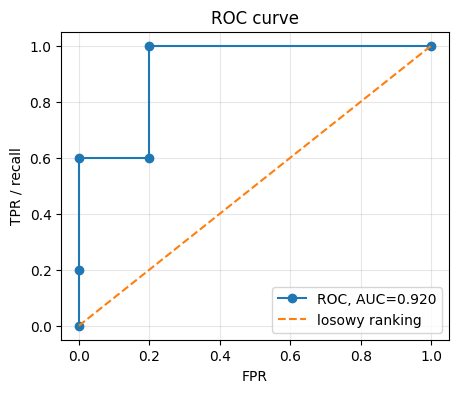

In [11]:
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, marker='o', label=f'ROC, AUC={auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='losowy ranking')
plt.xlabel('FPR')
plt.ylabel('TPR / recall')
plt.title('ROC curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Kiedy używać której metryki?

- Regresja, błędy w naturalnych jednostkach: `MAE`, `RMSE`.
- Regresja, porównanie z baseline'em średniej: $R^2$.
- Klasyfikacja z podobnymi kosztami błędów: `accuracy`.
- Gdy fałszywe alarmy są kosztowne: `precision`.
- Gdy przeoczenie pozytywu jest kosztowne: `recall/sensitivity`.
- Gdy interesuje nas ranking niezależnie od progu: `ROC/AUC`.
- Gdy wybieramy konkretną decyzję: threshold + confusion matrix.

## Proste ćwiczenia

1. Dla progu $t=0.7$ policz ręcznie TP, FP, TN, FN.
2. Dlaczego AUC liczymy na score/probability, a nie na klasach 0/1 po progu?
3. Kiedy model z gorszym accuracy może być lepszy praktycznie?
4. W regresji porównaj MAE i RMSE. Która metryka bardziej „boi się” dużego błędu?

## Rozwiązania — krótko

### 1. Dla progu $t=0.7$ policz TP, FP, TN, FN

Przyjmujemy regułę:

```python
score >= 0.7 -> klasa 1
score < 0.7  -> klasa 0
```

Wtedy:

* **TP** — prawdziwa klasa `1` i model przewidział `1`,
* **FP** — prawdziwa klasa `0`, ale model przewidział `1`,
* **TN** — prawdziwa klasa `0` i model przewidział `0`,
* **FN** — prawdziwa klasa `1`, ale model przewidział `0`.

Bez konkretnej tabeli `y_true` i `score` nie da się podać liczb, ale liczymy dokładnie według tej zasady.

---

### 2. Dlaczego AUC liczymy na score/probability, a nie na klasach 0/1?

Bo AUC ocenia **ranking**.

Czyli pyta:

> czy pozytywne przykłady mają zwykle wyższy score niż negatywne?

Po zamianie na klasy `0/1` tracimy informację, czy model dał np. `0.99`, `0.71` czy `0.51`.

---

### 3. Kiedy model z gorszym accuracy może być lepszy praktycznie?

Gdy koszty błędów są różne.

Przykład: badanie medyczne.

Model może mieć niższe `accuracy`, ale wyższy `recall`, czyli wykrywa więcej chorych. To może być praktycznie lepsze, jeśli przeoczenie choroby jest bardzo kosztowne.

---

### 4. MAE vs RMSE — która bardziej boi się dużego błędu?

**RMSE** bardziej boi się dużego błędu, bo błędy są podnoszone do kwadratu:

$$
RMSE=\sqrt{\frac{1}{n}\sum_i (y_i-\hat y_i)^2}
$$

**MAE** liczy wartość bezwzględną:

$$
MAE=\frac{1}{n}\sum_i |y_i-\hat y_i|
$$

Dlatego RMSE mocniej karze outliery.



## 6. Mini analiza na prawdziwych danych

Na koniec wykorzystamy te same idee z notebooka na realnych, małych zbiorach danych:

1. `previous_lecture_grades.csv` — krótka rozgrzewka: regresja oceny z liczby godzin nauki,
2. `seaborn_tips.csv` — większy przykład regresji: przewidywanie napiwku,
3. `seaborn_titanic.csv` — klasyfikacja binarna: przeżył / nie przeżył, confusion matrix, próg decyzyjny, ROC i AUC.

`grades.csv` jest bardzo czytelny dydaktycznie, ale ma tylko kilkadziesiąt obserwacji, więc nie traktujemy go jako stabilnej oceny modelu. Do bardziej sensownego pokazania metryk użyjemy większych zbiorów `tips` i `titanic`.


In [12]:

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

DATA_DIR = Path('.')

grades_path = DATA_DIR / 'previous_lecture_grades.csv'
tips_path = DATA_DIR / 'seaborn_tips.csv'
titanic_path = DATA_DIR / 'seaborn_titanic.csv'

for path in [grades_path, tips_path, titanic_path]:
    print(path, '->', path.exists())


previous_lecture_grades.csv -> True
seaborn_tips.csv -> True
seaborn_titanic.csv -> True


### 6.1. Rozgrzewka: `grades.csv` i metryki regresji

W tej krótkiej analizie traktujemy liczbę godzin nauki jako jedną cechę wejściową:

$$
X = \text{StudyHours}
$$

a ocenę jako zmienną, którą chcemy przewidzieć:

$$
y = \text{Grade}
$$

Budujemy bardzo prosty model:

$$
\widehat{Grade} = \beta_0 + \beta_1 \cdot StudyHours
$$

i porównujemy go z **baseline'em**, czyli modelem bazowym, który nie korzysta z `StudyHours`, tylko każdemu przykładowi przewiduje średnią ocenę ze zbioru treningowego:

$$
\widehat y_{baseline} = \overline y_{train}
$$

Wyniki ocenimy trzema skrótami:

- **MAE** — *Mean Absolute Error*, czyli średni błąd bezwzględny:  
  $$MAE = \frac{1}{n}\sum_i |y_i - \widehat y_i|$$
- **RMSE** — *Root Mean Squared Error*, czyli pierwiastek ze średniego błędu kwadratowego:  
  $$RMSE = \sqrt{\frac{1}{n}\sum_i (y_i - \widehat y_i)^2}$$
- **$R^2$** — współczynnik determinacji, czyli porównanie modelu z przewidywaniem średniej:  
  $$R^2 = 1 - \frac{\sum_i (y_i - \widehat y_i)^2}{\sum_i (y_i - \overline y)^2}$$

Dla `MAE` i `RMSE` mniejsze wartości są lepsze. Dla $R^2$ większa wartość jest lepsza.

In [13]:

grades = pd.read_csv(grades_path)
grades_clean = grades.dropna(subset=['StudyHours', 'Grade']).copy()

print('Rozmiar oryginalny:', grades.shape)
print('Rozmiar po usunięciu braków:', grades_clean.shape)

grades_clean.head()


Rozmiar oryginalny: (24, 3)
Rozmiar po usunięciu braków: (22, 3)


,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


In [14]:
# X to macierz cech wejściowych.
# Używamy podwójnych nawiasów [['StudyHours']], żeby X było DataFrame'em 2D,
# bo scikit-learn oczekuje danych w postaci: liczba_obserwacji x liczba_cech.
X = grades_clean[['StudyHours']]

# y to zmienna celu, czyli wartość, którą chcemy przewidzieć.
# Tutaj przewidujemy ocenę końcową Grade.
y = grades_clean['Grade']

# Dzielimy dane na zbiór treningowy i testowy.
# Model uczy się tylko na train, a jakość sprawdzamy na test.
# test_size=0.30 oznacza, że 30% obserwacji trafia do testu.
# random_state=42 zapewnia powtarzalny podział danych.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Tworzymy model regresji liniowej.
# Model będzie szukał zależności postaci:
# Grade_hat = beta_0 + beta_1 * StudyHours
lin_grade = LinearRegression()

# Dopasowujemy model tylko na danych treningowych.
lin_grade.fit(X_train, y_train)

# Predykcje modelu liniowego dla danych testowych.
y_pred = lin_grade.predict(X_test)

# Baseline, czyli model bazowy.
# Dla każdej osoby w teście przewiduje tę samą wartość:
# średnią ocenę ze zbioru treningowego.
# Baseline daje punkt odniesienia: model ML powinien być od niego lepszy.
y_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

# Funkcja pomocnicza licząca metryki regresji.
# y_true: prawdziwe wartości,
# y_hat: przewidziane wartości,
# label: nazwa modelu, którą pokażemy w tabeli.
def regression_metrics(y_true, y_hat, label):
    return {
        'model': label,
        # MAE: średnia wartość bezwzględna błędu. Mniejsze = lepiej.
        'MAE': mean_absolute_error(y_true, y_hat),
        # RMSE: pierwiastek ze średniego błędu kwadratowego.
        # Mocniej karze duże pomyłki niż MAE. Mniejsze = lepiej.
        'RMSE': mean_squared_error(y_true, y_hat) ** 0.5,
        # R2: porównanie z przewidywaniem średniej.
        # 1 oznacza model idealny, 0 oznacza poziom średniej, wartości ujemne są gorsze od średniej.
        'R2': r2_score(y_true, y_hat)
    }

# Porównujemy baseline z modelem liniowym na tym samym zbiorze testowym.
pd.DataFrame([
    regression_metrics(y_test, y_baseline, 'baseline: średnia z train'),
    regression_metrics(y_test, y_pred, 'LinearRegression: StudyHours -> Grade')
])

,model,MAE,RMSE,R2
0,baseline: średnia z train,24.9524,30.5252,-1.3414
1,LinearRegression: StudyHours -> Grade,8.6036,11.2056,0.6845


#### Krótka interpretacja wyników

Tabela porównuje dwa podejścia na zbiorze testowym:

1. **baseline: średnia z train** — model bazowy, który zawsze przewiduje jedną liczbę:

   $$
   \widehat y = \overline y_{train}
   $$

2. **LinearRegression: `StudyHours -> Grade`** — model, który wykorzystuje liczbę godzin nauki:

   $$
   \widehat{Grade} = \beta_0 + \beta_1 \cdot StudyHours
   $$

Wyniki pokazują, że model liniowy jest wyraźnie lepszy od baseline'u:

- `MAE` spada mniej więcej z $24.95$ do $8.60$, czyli średni błąd bezwzględny jest dużo mniejszy.
- `RMSE` spada mniej więcej z $30.53$ do $11.21$, więc model ma też mniej dużych pomyłek.
- $R^2$ rośnie z około $-1.34$ do około $0.68$.

Ujemne $R^2$ dla baseline'u oznacza, że na tym konkretnym podziale testowym przewidywanie średniej ze zbioru treningowego jest nawet gorsze niż punkt odniesienia oparty na średniej wartości w teście. To może się zdarzyć szczególnie przy małym zbiorze danych.

Najważniejszy wniosek:

$$
StudyHours \quad \text{zawiera informację pomocną do przewidywania} \quad Grade
$$

Nie traktujemy jednak tych liczb jako bardzo stabilnej oceny jakości, bo zbiór `grades.csv` jest mały. Wystarczy zmienić podział train/test i metryki mogą się zauważalnie zmienić.

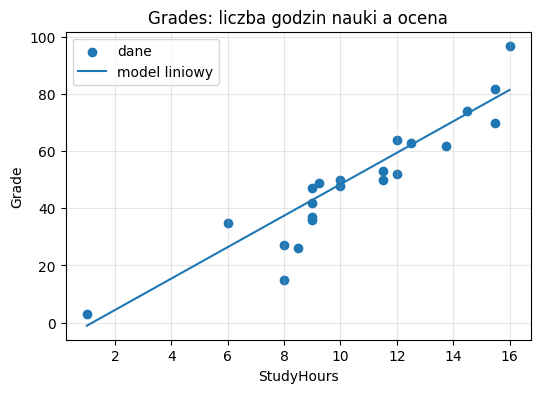

In [15]:

plt.figure(figsize=(6, 4))
plt.scatter(grades_clean['StudyHours'], grades_clean['Grade'], label='dane')

x_grid = np.linspace(grades_clean['StudyHours'].min(), grades_clean['StudyHours'].max(), 100)
y_grid = lin_grade.predict(pd.DataFrame({'StudyHours': x_grid}))
plt.plot(x_grid, y_grid, label='model liniowy')

plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title('Grades: liczba godzin nauki a ocena')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Wykres pokazuje tę samą zależność wizualnie: wraz ze wzrostem `StudyHours` rośnie przewidywana `Grade`.

Model liniowy rysuje prostą:

$$
\widehat{Grade} = \beta_0 + \beta_1 \cdot StudyHours
$$

Wniosek: to dobry przykład do zrozumienia metryk, ale przez małą liczbę obserwacji wynik testowy może mocno zależeć od podziału train/test. Dlatego w kolejnych sekcjach przechodzimy do większych zbiorów.


### 6.2. Większy przykład regresji: `tips.csv`

Teraz przewidujemy wysokość napiwku `tip`.

Użyjemy kilku cech:

- numeryczne: `total_bill`, `size`,
- kategoryczne: `sex`, `smoker`, `day`, `time`.

Celem jest nie idealny model, tylko pokazanie tych samych metryk regresji na większych danych.


In [16]:

tips = pd.read_csv(tips_path)
print(tips.shape)
tips.head()


(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [17]:

tip_features_num = ['total_bill', 'size']
tip_features_cat = ['sex', 'smoker', 'day', 'time']

X = tips[tip_features_num + tip_features_cat]
y = tips['tip']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), tip_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), tip_features_cat)
])

tip_model = Pipeline([
    ('preprocess', reg_preprocess),
    ('model', LinearRegression())
])

tip_model.fit(X_train, y_train)
y_pred = tip_model.predict(X_test)
y_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

pd.DataFrame([
    regression_metrics(y_test, y_baseline, 'baseline: średni napiwek z train'),
    regression_metrics(y_test, y_pred, 'LinearRegression: cechy rachunku -> tip')
])


,model,MAE,RMSE,R2
0,baseline: średni napiwek z train,1.0384,1.1983,-0.0794
1,LinearRegression: cechy rachunku -> tip,0.6975,0.9296,0.3504


In [18]:

tip_results = X_test.copy()
tip_results['true_tip'] = y_test.values
tip_results['pred_tip'] = y_pred
tip_results['error'] = tip_results['true_tip'] - tip_results['pred_tip']
tip_results['abs_error'] = tip_results['error'].abs()

tip_results.sort_values('abs_error', ascending=False).head(10)


,total_bill,size,sex,smoker,day,time,true_tip,pred_tip,error,abs_error
172,7.25,2,Male,Yes,Sun,Dinner,5.15,1.4672,3.6828,3.6828
153,24.55,4,Male,No,Sun,Dinner,2.00,3.9012,-1.9012,1.9012
109,14.31,2,Female,Yes,Sat,Dinner,4.00,2.1169,1.8831,1.8831
146,18.64,3,Female,No,Thur,Lunch,1.36,3.1482,-1.7882,1.7882
73,25.28,2,Female,Yes,Sat,Dinner,5.00,3.2200,1.7800,1.7800
156,48.17,6,Male,No,Sun,Dinner,5.00,6.6894,-1.6894,1.6894
211,25.89,4,Male,Yes,Sat,Dinner,5.16,3.7220,1.4380,1.4380
208,24.27,2,Male,Yes,Sat,Dinner,2.03,3.1459,-1.1159,1.1159
192,28.44,2,Male,Yes,Thur,Lunch,2.56,3.6734,-1.1134,1.1134
200,18.71,3,Male,Yes,Thur,Lunch,4.00,2.9016,1.0984,1.0984


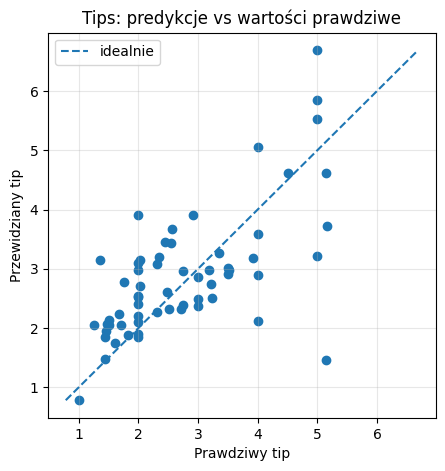

In [19]:

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='idealnie')
plt.xlabel('Prawdziwy tip')
plt.ylabel('Przewidziany tip')
plt.title('Tips: predykcje vs wartości prawdziwe')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Interpretacja:

- `MAE` jest w dolarach napiwku i łatwo go czytać,
- `RMSE` będzie większe, jeśli pojawią się pojedyncze duże błędy,
- $R^2$ mówi, czy model jest lepszy od przewidywania jednej średniej wartości.



### 6.3. Klasyfikacja: `titanic.csv`

Teraz robimy klasyfikację binarną. Zmienna celu:

$$
Survived = 1 \quad \text{jeśli pasażer przeżył}
$$

Użyjemy regresji logistycznej i policzymy:

- confusion matrix,
- accuracy, precision, recall, specificity, F1,
- metryki dla różnych progów decyzyjnych,
- ROC i AUC.


In [20]:

titanic = pd.read_csv(titanic_path)
print(titanic.shape)
titanic.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [21]:

cls_features_num = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cls_features_cat = ['sex', 'embarked', 'alone']

X = titanic[cls_features_num + cls_features_cat]
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cls_preprocess = ColumnTransformer([
    ('num', num_pipe, cls_features_num),
    ('cat', cat_pipe, cls_features_cat)
])

titanic_model = Pipeline([
    ('preprocess', cls_preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

titanic_model.fit(X_train, y_train)

# Prawdopodobieństwo klasy 1, czyli survived=1.
y_score = titanic_model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_score >= 0.5).astype(int)

print('Odsetek klasy pozytywnej w train:', y_train.mean().round(3))
print('Odsetek klasy pozytywnej w test:', y_test.mean().round(3))


Odsetek klasy pozytywnej w train: 0.383
Odsetek klasy pozytywnej w test: 0.386


In [22]:

cm = confusion_matrix(y_test, y_pred_05)
cm_df = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
cm_df


,pred_0,pred_1
actual_0,115,22
actual_1,26,60


In [23]:

def classification_metrics_from_cm(y_true, y_pred, label='model'):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    specificity = TN / (TN + FP) if (TN + FP) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
    return {
        'model': label,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'TP': TP,
        'accuracy': accuracy,
        'precision': precision,
        'recall/sensitivity': recall,
        'specificity': specificity,
        'F1': f1
    }

# Baseline: zawsze przewiduje klasę większościową z train.
majority_class = int(y_train.mode().iloc[0])
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

pd.DataFrame([
    classification_metrics_from_cm(y_test, y_pred_baseline, 'baseline: klasa większościowa'),
    classification_metrics_from_cm(y_test, y_pred_05, 'LogisticRegression, threshold=0.5')
])


,model,TN,FP,FN,TP,accuracy,precision,recall/sensitivity,specificity,F1
0,baseline: klasa większościowa,137,0,86,0,0.6143,NaN,0.0000,1.0000,NaN
1,"LogisticRegression, threshold=0.5",115,22,26,60,0.7848,0.7317,0.6977,0.8394,0.7143



W tym miejscu widać różnicę między samą klasyfikacją `0/1` a score/prawdopodobieństwem. Confusion matrix zależy od wybranego progu, dlatego sprawdźmy kilka progów.


In [24]:

def threshold_report(y_true, y_score, thresholds):
    rows = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        row = classification_metrics_from_cm(y_true, y_pred, label=f't={t}')
        row['threshold'] = t
        rows.append(row)
    return pd.DataFrame(rows)[[
        'threshold', 'TN', 'FP', 'FN', 'TP',
        'accuracy', 'precision', 'recall/sensitivity', 'specificity', 'F1'
    ]]

threshold_report(y_test, y_score, thresholds=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])


,threshold,TN,FP,FN,TP,accuracy,precision,recall/sensitivity,specificity,F1
0,0.2,83,54,12,74,0.7040,0.5781,0.8605,0.6058,0.6916
1,0.3,98,39,15,71,0.7578,0.6455,0.8256,0.7153,0.7245
2,0.4,106,31,18,68,0.7803,0.6869,0.7907,0.7737,0.7351
3,0.5,115,22,26,60,0.7848,0.7317,0.6977,0.8394,0.7143
4,0.6,127,10,31,55,0.8161,0.8462,0.6395,0.9270,0.7285
5,0.7,131,6,42,44,0.7848,0.8800,0.5116,0.9562,0.6471
6,0.8,134,3,60,26,0.7175,0.8966,0.3023,0.9781,0.4522



Interpretacja progu:

- niższy próg zwykle zwiększa `recall`, bo model łatwiej oznacza przypadek jako pozytywny,
- wyższy próg zwykle zwiększa ostrożność modelu i może zmniejszyć liczbę fałszywych alarmów,
- wybór progu zależy od kosztu błędów `FP` i `FN`.


In [25]:

fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
auc_value = roc_auc_score(y_test, y_score)

roc_summary = pd.DataFrame({
    'threshold': roc_thresholds,
    'FPR': fpr,
    'TPR/recall': tpr
})

print('ROC AUC:', round(auc_value, 3))
roc_summary.head(10)


ROC AUC: 0.847


,threshold,FPR,TPR/recall
0,inf,0.0000,0.0000
1,0.9729,0.0073,0.0000
2,0.8434,0.0073,0.2791
3,0.8104,0.0219,0.2791
4,0.7613,0.0219,0.4186
5,0.7419,0.0365,0.4186
6,0.7376,0.0365,0.4419
7,0.7279,0.0365,0.4767
8,0.7245,0.0365,0.5000
9,0.7065,0.0438,0.5000


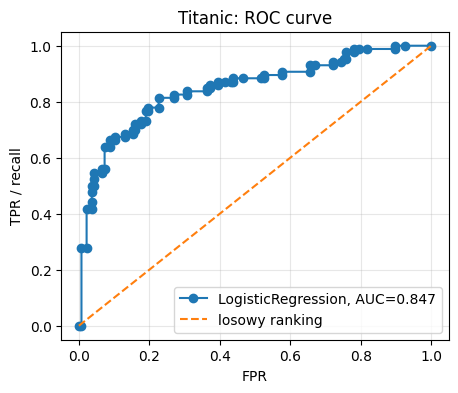

In [26]:

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, marker='o', label=f'LogisticRegression, AUC={auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='losowy ranking')
plt.xlabel('FPR')
plt.ylabel('TPR / recall')
plt.title('Titanic: ROC curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### 6.4. Krótkie podsumowanie

W tej końcowej analizie użyliśmy dokładnie tych samych pojęć, które pojawiły się wcześniej w notebooku:

- dla regresji: `MAE`, `RMSE`, $R^2$ oraz porównanie z baseline'em,
- dla klasyfikacji: confusion matrix, `accuracy`, `precision`, `recall`, `specificity`, `F1`,
- dla modeli zwracających score/prawdopodobieństwo: próg decyzyjny, ROC i AUC.

Najważniejsza praktyczna intuicja:

> Metryka nie jest dodatkiem na końcu. Metryka definiuje, co w danym problemie uznajemy za „dobry model”.


## 7. Mini-lab: jedna klasyfikacja, wiele metryk — Titanic

Teraz używamy jednego problemu klasyfikacji i liczymy wiele metryk naraz.

Pytanie:

$$
\text{Czy jedna liczba wystarczy, żeby ocenić klasyfikator?}
$$

Zwykle nie. Dlatego patrzymy jednocześnie na:

$$
accuracy,\ precision,\ recall,\ F1,\ AUC
$$


In [27]:
from pathlib import Path

def find_data_file(filename):
    """Znajduje plik CSV niezależnie od tego, z jakiego katalogu uruchamiamy notebook."""
    candidates = [
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path.cwd() / 'data' / filename,
        Path.cwd().parent / 'data' / filename,
        Path('/mnt/data') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Nie znaleziono pliku: {filename}')

def make_onehot_encoder():
    """Kompatybilność ze starszym i nowszym scikit-learn: sparse vs sparse_output."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, r2_score
)

def positive_score(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return None

def binary_metrics(y_true, y_pred, y_score=None):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out['auc'] = roc_auc_score(y_true, y_score)
    return out

titanic = pd.read_csv(find_data_file('seaborn_titanic.csv'))
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'pclass', 'embarked']
X = titanic[numeric_features + categorical_features]
y = titanic['survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_onehot_encoder())
    ]), categorical_features)
])


### 7.1. Baseline vs kilka modeli

Metryki są niezależne od algorytmu. Ten sam zestaw metryk możemy policzyć dla baseline'u, regresji logistycznej, drzewa i lasu losowego.


In [28]:
models = {
    'baseline: majority class': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'DecisionTree depth=3': DecisionTreeClassifier(max_depth=3, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

rows = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = positive_score(pipe, X_test)
    rows.append({'model': name, **binary_metrics(y_test, pred, score)})
    fitted_models[name] = pipe

pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)


,model,accuracy,precision,recall,f1,auc
0,RandomForest,0.8172,0.8462,0.6408,0.7293,0.8606
1,LogisticRegression,0.7985,0.7579,0.6990,0.7273,0.8485
2,DecisionTree depth=3,0.7948,0.8750,0.5437,0.6707,0.8295
3,baseline: majority class,0.6157,0.0000,0.0000,0.0000,0.5000


### 7.2. Ten sam model, różne progi decyzyjne

Model logistyczny zwraca prawdopodobieństwo:

$$
P(y=1 \mid X)
$$

Decyzja klasyfikacyjna wymaga progu $t$:

$$
\hat y =
\begin{cases}
1, & P(y=1\mid X) \ge t \\
0, & P(y=1\mid X) < t
\end{cases}
$$


In [29]:
logreg_pipe = fitted_models['LogisticRegression']
logreg_score = logreg_pipe.predict_proba(X_test)[:, 1]

threshold_rows = []
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred_t = (logreg_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    threshold_rows.append({
        'threshold': t,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'accuracy': accuracy_score(y_test, pred_t),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })

pd.DataFrame(threshold_rows)


,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1
0,0.2,102,63,15,88,0.7090,0.5828,0.8544,0.6929
1,0.3,123,42,18,85,0.7761,0.6693,0.8252,0.7391
2,0.4,134,31,21,82,0.8060,0.7257,0.7961,0.7593
3,0.5,142,23,31,72,0.7985,0.7579,0.6990,0.7273
4,0.6,153,12,37,66,0.8172,0.8462,0.6408,0.7293
5,0.7,159,6,48,55,0.7985,0.9016,0.5340,0.6707
6,0.8,162,3,66,37,0.7425,0.9250,0.3592,0.5175


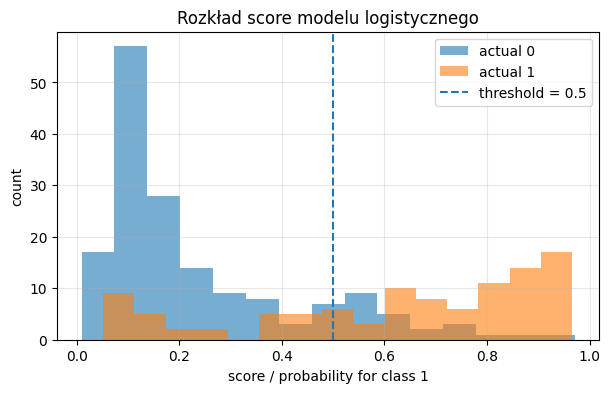

In [30]:
plt.figure(figsize=(7, 4))
plt.hist(logreg_score[y_test.to_numpy() == 0], bins=15, alpha=0.6, label='actual 0')
plt.hist(logreg_score[y_test.to_numpy() == 1], bins=15, alpha=0.6, label='actual 1')
plt.axvline(0.5, linestyle='--', label='threshold = 0.5')
plt.xlabel('score / probability for class 1')
plt.ylabel('count')
plt.title('Rozkład score modelu logistycznego')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 7.3. ROC i AUC dla kilku modeli

ROC pokazuje wiele progów naraz. AUC streszcza jakość rankingu.


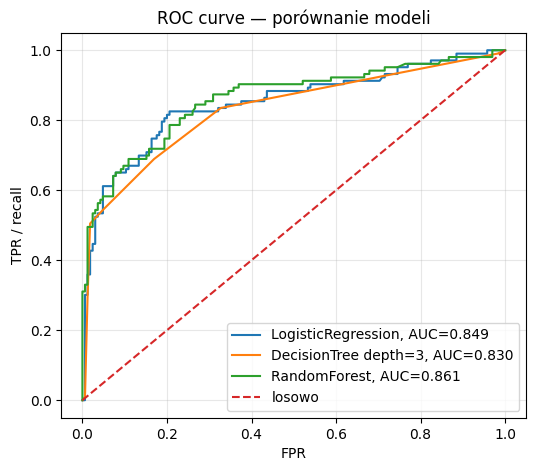

In [31]:
plt.figure(figsize=(6, 5))

for name in ['LogisticRegression', 'DecisionTree depth=3', 'RandomForest']:
    score = positive_score(fitted_models[name], X_test)
    fpr, tpr, _ = roc_curve(y_test, score)
    model_auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f'{name}, AUC={model_auc:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', label='losowo')
plt.xlabel('FPR')
plt.ylabel('TPR / recall')
plt.title('ROC curve — porównanie modeli')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Czy $R^2$ to korelacja?

Korelacja Pearsona to $r$. Współczynnik determinacji to $R^2$.

W prostej regresji liniowej z jedną cechą i wyrazem wolnym zachodzi:

$$
R^2 = r^2
$$

ale ogólnie lepiej zapamiętać:

$$
r = \text{korelacja}, \qquad R^2 = \text{jakość wyjaśniania zmienności przez model}
$$


In [32]:
grades = pd.read_csv(find_data_file('previous_lecture_grades.csv'))
grades_clean = grades.dropna(subset=['StudyHours', 'Grade']).copy()

X_g = grades_clean[['StudyHours']]
y_g = grades_clean['Grade']

r = np.corrcoef(grades_clean['StudyHours'], grades_clean['Grade'])[0, 1]
lin_full = LinearRegression()
lin_full.fit(X_g, y_g)
r2_full = r2_score(y_g, lin_full.predict(X_g))

pd.DataFrame({
    'quantity': ['Pearson r', 'r^2', 'R2 modelu na pełnym zbiorze'],
    'value': [r, r ** 2, r2_full]
})


,quantity,value
0,Pearson r,0.9254
1,r^2,0.8564
2,R2 modelu na pełnym zbiorze,0.8564


## 9. Most do kolejnych modeli

W kolejnych notebookach zmienia się algorytm, ale logika oceny zostaje taka sama:

$$
\text{baseline} \rightarrow \text{model} \rightarrow \text{metryki na test} \rightarrow \text{wniosek}
$$

| Model | Główna intuicja | Pytanie kontrolne |
|---|---|---|
| KNN | podobne punkty są blisko | czy skala cech nie psuje odległości? |
| Drzewo | reguły `if/else` | czy drzewo nie jest za głębokie? |
| SVM | margines i kernel | czy skalowanie i kernel pomagają? |
| Random Forest | wiele drzew głosuje razem | czy ensemble stabilizuje wynik? |
| Manifold learning | wizualizacja struktury | czy obrazek nie zastępuje metryk? |
